In [1]:
import pandas as pd #pacote para manipulação de dados (meu excel no pyhton)
import numpy as np #pacote otimo para fazer calculos matematicos
import matplotlib.pyplot as plt #pacote para gerar graficos
import seaborn as sns #pacote para embelezar meus graficos

In [2]:
dados = pd.read_excel("DadosClientes.xlsx") #banco de dados fictício

In [25]:
n_simulacoes = 10000 #selecionando a quantidade de simulações que quero, ajuda na manutenção depois se eu quiser
resultados_perda = []

In [13]:
taxa_perda_real = 0.2 #A porcentagem de quanto vou perder tirando as garantias

In [26]:
for i in range(n_simulacoes): #começo o looping
    sorteio_pd = np.random.rand(1000) #usando essa função do pacote numpy, consigo sortear valores de 0 a 1 para todos os clientes (pois estamos usando a Probability of Default)
    calotes = (sorteio_pd < dados['PD']).astype(int) #guardo em calotes todos os valores que foram sorteados como nao pagadores
    perda_total = (calotes * dados['VALOR FINANCIADO'] * taxa_perda_real).sum() #e em perda total, eu tenho a soma de todos os valores de emprestimo que foram sorteados que não vai pagar ja tirando as garantias
    resultados_perda.append(perda_total) #guardo tudo na minha variavel resultado perda q defini acima 

In [27]:
perda_media = np.mean(resultados_perda) #aqui entra a parte estatistica, que é fazer a media de cada perda dos 10 000 cenarios
var_95 = np.percentile(resultados_perda, 95) #depois colocamos em ordem crescente para conseguirmos saber o nosso valor minimo e maximo de perda, e chegando em 95% dos resultados, posso afirmar que em 95% das vezes, o valor nao ultrapassou o valor do "lugar" 9.500 na ordem de valores

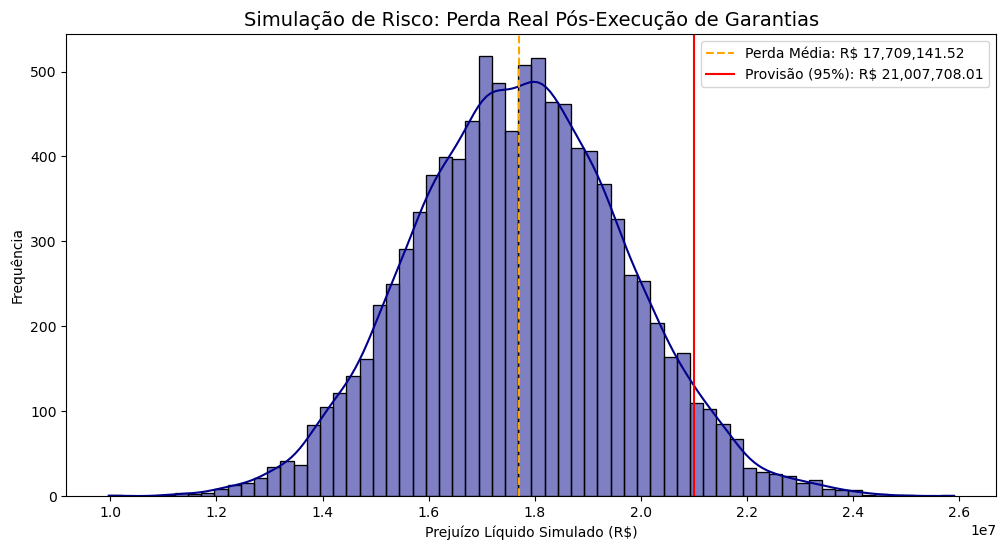

In [28]:
plt.figure(figsize=(12, 6))

#Histograma dos valores perdidos de cada cenario, colocando a media no centro
sns.histplot(resultados_perda, kde=True, color='darkblue')

# 2. As linhas de estatística
plt.axvline(perda_media, color='orange', linestyle='--', label=f'Perda Média: R$ {perda_media:,.2f}') #A perda media olhando todos os cenarios
plt.axvline(var_95, color='red', linestyle='-', label=f'Provisão (95%): R$ {var_95:,.2f}') #usando o percentil 95%, posso provisionar um valor que vai cobrir 95% das perdas possiveis 

# 3. Títulos e Legendas
plt.title('Simulação de Risco: Perda Real Pós-Execução de Garantias', fontsize=14)
plt.xlabel('Prejuízo Líquido Simulado (R$)')
plt.ylabel('Frequência')
plt.legend() # Agora a legenda vai funcionar!

plt.show()

In [8]:
# Mostrando os números reais
print(f"--- RELATÓRIO DE RISCO DA CARTEIRA ---")
print(f"Valor Total Emprestado: R$ {dados['VALOR FINANCIADO'].sum():,.2f}")
print(f"Perda Média Esperada: R$ {perda_media:,.2f}")
print(f"Provisionamento (VaR 95%): R$ {var_95:,.2f}")
print(f"Risco Extremo (VaR 99%): R$ {np.percentile(resultados_perda, 99):,.2f}")
print(f"Pior Cenário Simulado: R$ {max(resultados_perda):,.2f}")
print(f"Melhor Cenário Simulado: R$ {min(resultados_perda):,.2f}")

--- RELATÓRIO DE RISCO DA CARTEIRA ---
Valor Total Emprestado: R$ 1,044,999,435.00
Perda Média Esperada: R$ 17,729,565.82
Provisionamento (VaR 95%): R$ 21,046,698.51
Risco Extremo (VaR 99%): R$ 22,396,029.24
Pior Cenário Simulado: R$ 25,547,394.00
Melhor Cenário Simulado: R$ 10,567,629.00
